In [81]:
import os
import time
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

In [82]:
sns.set_style("whitegrid")
tf.keras.utils.set_random_seed(123)

KFOLD_DIR = r'D:/Do_An/Data_Final/kfold_splits' 
SAVE_DIR = r'saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE = 224 
BATCH_SIZE = 32
EPOCHS_PHASE1 = 15
EPOCHS_PHASE2 = 20
K_FOLDS = 5

UNFREEZE_PERCENT = 0.25       
LR_PHASE2 = 1e-5

In [83]:
# DATA AUGMENTATION
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='reflect'
)

# Chỉ chuẩn hóa (preprocess) cho tập Val và Test
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [84]:
# XÂY DỰNG MÔ HÌNH (FINE-TUNING)
def build_model():
    base_model = EfficientNetB0(weights='imagenet', include_top=False, 
                                input_shape=(IMG_SIZE, IMG_SIZE, 3))
    
    # Freeze toàn bộ ở Phase 1
    for layer in base_model.layers:
        layer.trainable = False
    
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs=base_model.input, outputs=outputs)
    return model, base_model

In [85]:
def unfreeze_model(base_model):
    total_layers = len(base_model.layers)
    unfreeze_from = int(total_layers * (1 - UNFREEZE_PERCENT))

    print(f"Unfreeze từ layer {unfreeze_from}/{total_layers}")

    for i, layer in enumerate(base_model.layers):
        layer.trainable = i >= unfreeze_from

    # Freeze BatchNorm (quan trọng)
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

In [ ]:
def train_one_fold(fold):
    print(f"\nTRAIN FOLD {fold}/5")

    fold_dir = os.path.join(KFOLD_DIR, f'fold_{fold}')

    train_gen = train_datagen.flow_from_directory(
        os.path.join(fold_dir, 'train'),
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='binary'
    )

    val_gen = val_test_datagen.flow_from_directory(
        os.path.join(fold_dir, 'val'),
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )

    test_gen = val_test_datagen.flow_from_directory(
        os.path.join(fold_dir, 'test'),
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )

    model, base_model = build_model()

    # ===== CALLBACKS =====
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=7,
            restore_best_weights=True,
            verbose=1   
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=os.path.join(SAVE_DIR, f'EffB0_Fold_{fold}_best.keras'),
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        )
    ]

    # PHASE 1 
    print("\nPHASE 1: Train Head")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    h1 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS_PHASE1,
        callbacks=callbacks,
        verbose=1
    )

    #PHASE 2
    print("\nPHASE 2: Fine-tuning")

    unfreeze_model(base_model)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(LR_PHASE2),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    h2 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS_PHASE2,
        callbacks=callbacks,
        verbose=1
    )

    # EVALUATE 
    test_loss, test_acc = model.evaluate(test_gen, verbose=0)

    print(f"Fold {fold} - Test Accuracy: {test_acc*100:.2f}% | Loss: {test_loss:.4f}")

    # HISTORY
    history = {
        'loss': h1.history['loss'] + h2.history['loss'],
        'val_loss': h1.history['val_loss'] + h2.history['val_loss'],
        'accuracy': h1.history['accuracy'] + h2.history['accuracy'],
        'val_accuracy': h1.history['val_accuracy'] + h2.history['val_accuracy']
    }

    return test_acc, history, test_gen

In [87]:
start_time = time.time()

best_acc = 0
best_history = None
best_test_gen = None
best_model_path = None
best_fold_idx = 0  

accs = []

for fold in range(1, K_FOLDS + 1):
    
    fold_start = time.time()
    
    acc, hist, test_gen = train_one_fold(fold)
    accs.append(acc)

    fold_time = time.time() - fold_start
    print(f"Fold {fold} time: {fold_time:.2f}s")

    if acc > best_acc:
        best_acc = acc
        best_history = hist
        best_test_gen = test_gen
        best_model_path = os.path.join(SAVE_DIR, f'EffB0_Fold_{fold}_best.keras')
        best_fold_idx = fold   

# TOTAL TIME 
total_time = time.time() - start_time
h, rem = divmod(total_time, 3600)
m, s = divmod(rem, 60)

print("\nKẾT QUẢ")
print(f"Mean Accuracy: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Best Fold: {best_fold_idx} (Acc = {best_acc:.4f})")
print(f"Total time: {int(h)}h {int(m)}m {int(s)}s")


TRAIN FOLD 1/5
Found 1911 images belonging to 2 classes.
Found 337 images belonging to 2 classes.
Found 562 images belonging to 2 classes.

PHASE 1: Train Head
Epoch 1/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 817ms/step - accuracy: 0.8814 - loss: 0.2872
Epoch 1: val_accuracy improved from None to 0.98813, saving model to saved_models\EffB0_Fold_1_best.keras

Epoch 1: finished saving model to saved_models\EffB0_Fold_1_best.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 68s 987ms/step - accuracy: 0.9388 - loss: 0.1555 - val_accuracy: 0.9881 - val_loss: 0.0960 - learning_rate: 0.0010
Epoch 2/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - accuracy: 0.9802 - loss: 0.0559
Epoch 2: val_accuracy did not improve from 0.98813
60/60 ━━━━━━━━━━━━━━━━━━━━ 55s 913ms/step - accuracy: 0.9733 - loss: 0.0734 - val_accuracy: 0.9852 - val_loss: 0.0706 - learning_rate: 0.0010
Epoch 3/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 801ms/step - accuracy: 0.9876 - loss: 0.0411
Epoch 3: val_accuracy improved from 0.98813 to 0.99407, saving model

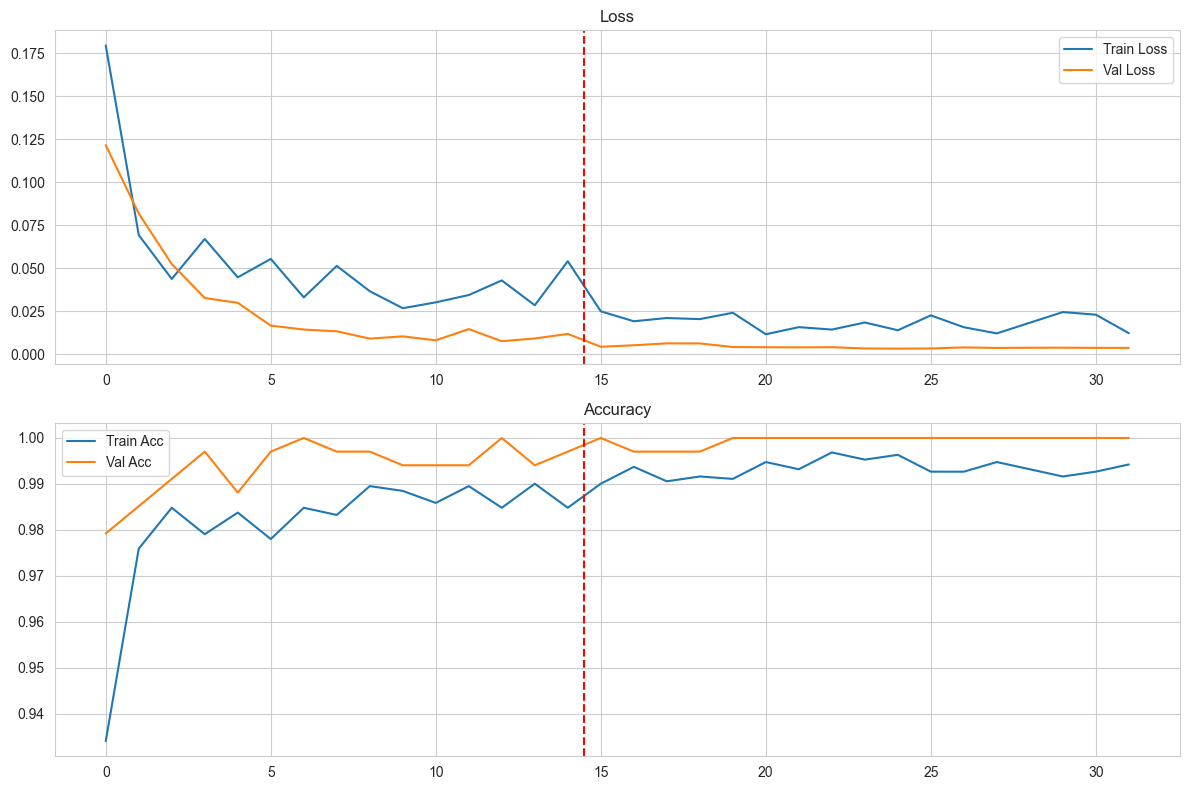

In [88]:
plt.figure(figsize=(12,8))

plt.subplot(2,1,1)
plt.plot(best_history['loss'], label='Train Loss')
plt.plot(best_history['val_loss'], label='Val Loss')
plt.axvline(x=EPOCHS_PHASE1 - 0.5, color='red', linestyle='--')
plt.legend()
plt.title("Loss")

plt.subplot(2,1,2)
plt.plot(best_history['accuracy'], label='Train Acc')
plt.plot(best_history['val_accuracy'], label='Val Acc')
plt.axvline(x=EPOCHS_PHASE1 - 0.5, color='red', linestyle='--')
plt.legend()
plt.title("Accuracy")

plt.tight_layout()
plt.show()

In [89]:
best_model = tf.keras.models.load_model(best_model_path)

# ================= PREDICT =================
best_test_gen.reset()
pred = best_model.predict(best_test_gen)
pred_classes = (pred > 0.5).astype(int).reshape(-1)

true = best_test_gen.classes
names = list(best_test_gen.class_indices.keys())

18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 733ms/step


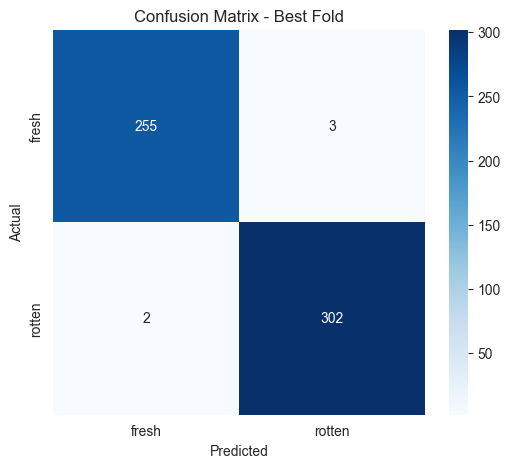

In [90]:
# Ma Trận Nhầm Lẫn (Confusion Matrix)
cm = confusion_matrix(true, pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=names, yticklabels=names)
plt.title("Confusion Matrix - Best Fold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [91]:
# Classification Report
print("\nBÁO CÁO PHÂN LOẠI:")
print(classification_report(true_classes, pred_classes, target_names=class_names))


BÁO CÁO PHÂN LOẠI:
              precision    recall  f1-score   support

       fresh       0.99      0.99      0.99       258
      rotten       0.99      0.99      0.99       304

    accuracy                           0.99       562
   macro avg       0.99      0.99      0.99       562
weighted avg       0.99      0.99      0.99       562



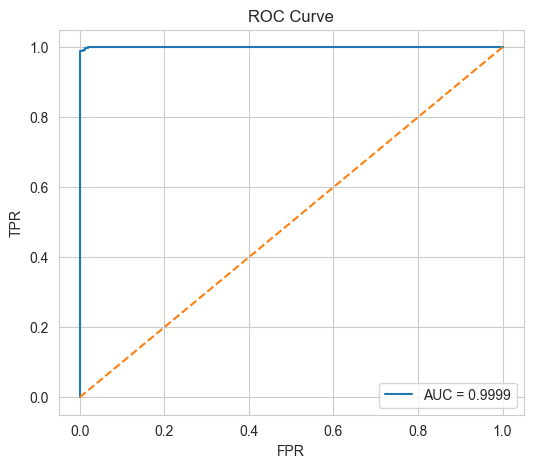

In [92]:
# ROC Curve
fpr, tpr, _ = roc_curve(true, pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()



Có 5 ảnh dự đoán sai


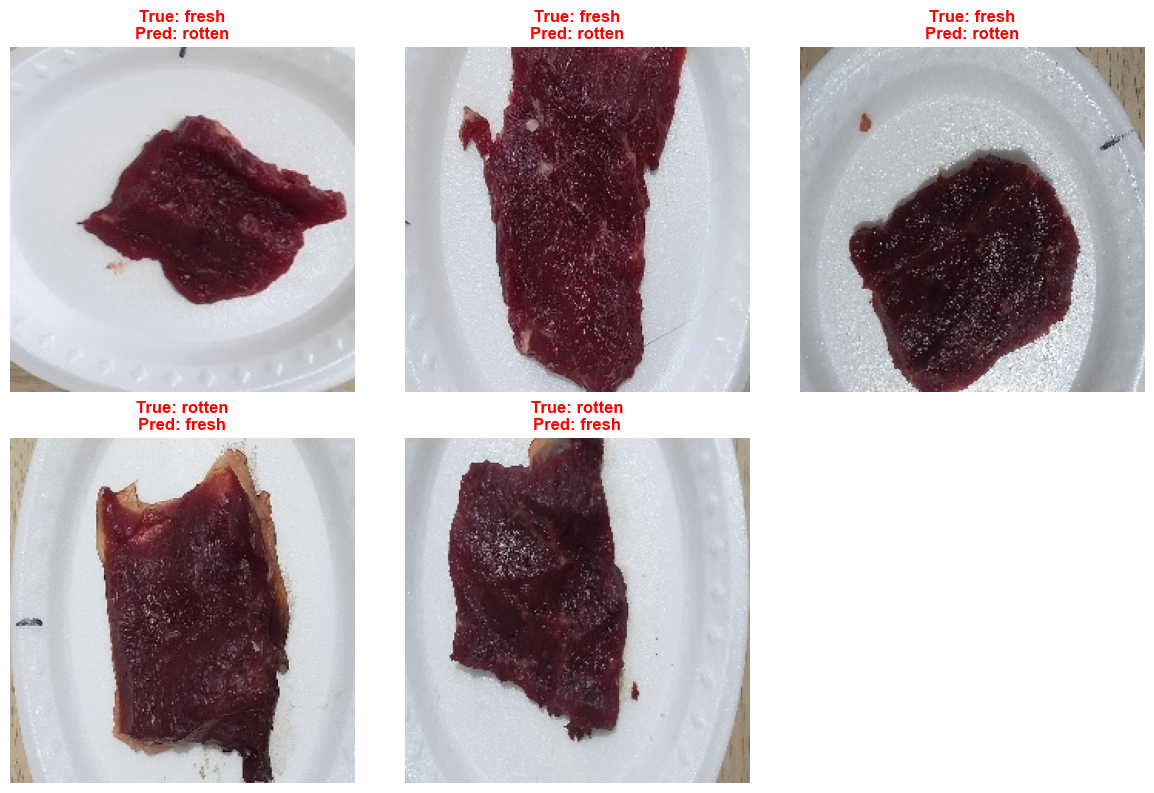

In [93]:
# Ảnh Dự Đoán Sai
misclassified = np.where(pred_classes != true)[0]

if len(misclassified) > 0:
    print(f"\nCó {len(misclassified)} ảnh dự đoán sai")

    plt.figure(figsize=(12, 8))
    for i, idx in enumerate(misclassified[:6]):  # show 6 ảnh
        img_path = best_test_gen.filepaths[idx]
        img = plt.imread(img_path)

        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(
            f"True: {names[true[idx]]}\nPred: {names[pred_classes[idx]]}",
            color='red', fontweight='bold'
        )
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("\nModel dự đoán đúng toàn bộ test set")

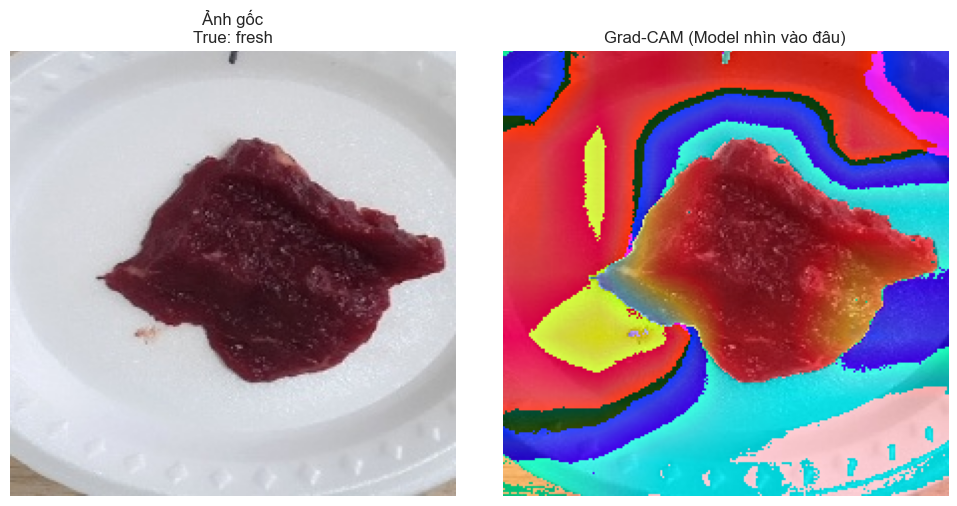

In [96]:
from PIL import Image
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)

    if max_val == 0:
        return np.zeros_like(heatmap.numpy())

    heatmap /= max_val

    return heatmap.numpy()

last_conv_layer_name = "top_conv"

target_idx = misclassified[0] if len(misclassified) > 0 else 0
img_path = best_test_gen.filepaths[target_idx]

img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

heatmap = make_gradcam_heatmap(img_array, best_model, last_conv_layer_name)

img_orig = np.array(Image.open(img_path).convert("RGB"))

heatmap = cv2.resize(heatmap, (img_orig.shape[1], img_orig.shape[0]))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img_orig
superimposed_img = np.uint8(superimposed_img)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_orig)
plt.title(f"Ảnh gốc\nTrue: {names[true[target_idx]]}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(superimposed_img)
plt.title("Grad-CAM (Model nhìn vào đâu)")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
print(f"\nĐã lưu biểu đồ tất cả các fold tại: {SAVE_DIR}/All_Folds_Loss_Accuracy.png")
print(f"Best model được lưu tại: {SAVE_DIR}/EffB0_Fold_{best_fold}_best.keras")


Đã lưu biểu đồ tất cả các fold tại: saved_models/All_Folds_Loss_Accuracy.png
Best model được lưu tại: saved_models/EffB0_Fold_3_best.keras
